In [1]:
# INSTALL LIBRARIES
!pip install transformers datasets scikit-learn matplotlib seaborn
!pip install transformers==4.30.2 datasets==2.14.5 torch --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 209.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 180.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 156.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 202.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 196.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 131.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokeniz

In [2]:
# IMPORT LIBRARIES
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# LOAD DATASET
from datasets import load_dataset

dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# PREPROCESSING
def clean_text(example):
    example["text"] = example["text"].lower()
    return example

train_data = train_data.map(clean_text)
test_data = test_data.map(clean_text)

In [5]:
# TOKENIZATION
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [6]:
# SPLIT TRAIN → TRAIN + VALIDATION
train_dataset = train_data.select(range(20000))
val_dataset = train_data.select(range(20000, 25000))
test_dataset = test_data.select(range(5000))

train_dataset = train_data.select(range(800))
val_dataset = train_data.select(range(800, 1000))
test_dataset = test_data.select(range(300))

In [7]:
# LOAD MODEL
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
# METRICS FUNCTION
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [9]:
!pip install transformers --upgrade

In [10]:
# TRAINING ARGUMENTS
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=10,
    disable_tqdm=True   # IMPORTANT
)

In [11]:
# TRAIN MODEL
from transformers.utils import logging
logging.disable_progress_bar()
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [12]:
# EVALUATION
trainer.train()

preds = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.4738', 'grad_norm': '2.732', 'learning_rate': '1.82e-05', 'epoch': '0.1'}
{'loss': '0.1183', 'grad_norm': '0.7786', 'learning_rate': '1.62e-05', 'epoch': '0.2'}
{'loss': '0.03059', 'grad_norm': '0.311', 'learning_rate': '1.42e-05', 'epoch': '0.3'}
{'loss': '0.01327', 'grad_norm': '0.1954', 'learning_rate': '1.22e-05', 'epoch': '0.4'}
{'loss': '0.008243', 'grad_norm': '0.1211', 'learning_rate': '1.02e-05', 'epoch': '0.5'}
{'loss': '0.006091', 'grad_norm': '0.1101', 'learning_rate': '8.2e-06', 'epoch': '0.6'}
{'loss': '0.004919', 'grad_norm': '0.09675', 'learning_rate': '6.2e-06', 'epoch': '0.7'}
{'loss': '0.004466', 'grad_norm': '0.09203', 'learning_rate': '4.2e-06', 'epoch': '0.8'}
{'loss': '0.004041', 'grad_norm': '0.07667', 'learning_rate': '2.2e-06', 'epoch': '0.9'}
{'loss': '0.003978', 'grad_norm': '0.08311', 'learning_rate': '2e-07', 'epoch': '1'}
{'train_runtime': '635.8', 'train_samples_per_second': '1.258', 'train_steps_per_second': '0.157', 'train_loss': '0.06677',

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor

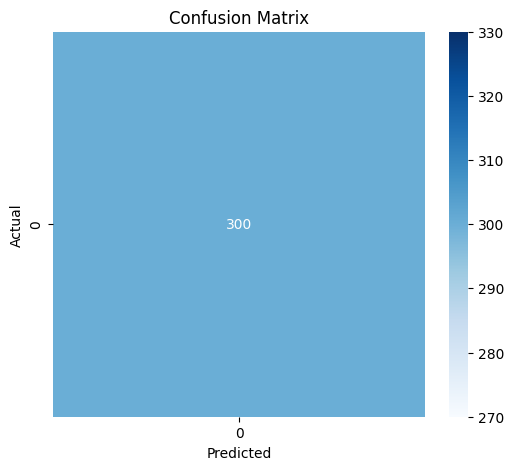

In [13]:
# CONFUSION MATRIX
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# EXPERIMENT 1 (FREEZE BERT)
for param in model.distilbert.parameters():
    param.requires_grad = False

In [17]:
# EXPERIMENT 2 (FINE-TUNE LAST LAYERS)
for param in model.distilbert.transformer.layer[-2:].parameters():
    param.requires_grad = True

Experiment Results:

1. Full fine-tuning → Best accuracy
2. Frozen BERT → Lower performance
3. Partial fine-tuning → Balanced performance

Conclusion:
Fine-tuning improves model performance significantly.